In [3]:
import sys
sys.path.insert(0, '../../')

In [4]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.base import clone
from tqdm import tqdm
from pickle import load

# load local variables
from src.config import *
from src.load_models import select_model
from src.utils import calculate_r2_score, calculate_per_diff
from src.utils import calculate_y_LOD, find_score
from src.feature_selection import ModelSelection
from src.graph_visualization import feature_selection_tabularize, plot_model_vs_score, visualization_class_stratified
from src.outlier_detection import find_outliers_remove
from src.utils import evaluate_score_class_stratified

from sklearn.ensemble  import RandomForestClassifier

from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process.kernels import Matern, RBF

In [21]:
    
def testPerformanceWithStratified(X:pd.DataFrame,
                                    y:pd.Series,
                                    models:list,
                                    save_dir:str,
                                    weight_path:str,
                                    features_list:dict, 
                                    param_list:dict,
                                    y_LOD:float = 1.0163597575709407,
                                    use_classifier:bool=False) -> None:

    
    per_diff_class_stratified_test = {'Models':[]}
    for key in sorted(y.unique()):
        per_diff_class_stratified_test[str(key)] = []
    
    
    os.makedirs(save_dir, exist_ok=True)
    print("y_LOD", y_LOD)

    # Zero concentration classifier
    if use_classifier:
        with open(f'{weight_path}/classification_weight.pkl', 'rb') as f:
            model_classifier = load(f)
        
    for metric in ['r2', 'per_diff']:
        test_score = {'Models':[], 'Scores':[]}
        for model_name in models:
            with open(f'{weight_path}/{model_name}.pkl', 'rb') as f:
                model = load(f)
                
            selected_feature_set = features_list[model_name]
            
            # Calculate the test score on the given performance metrics
            test_score['Models'].append(model_name)

            y_pred = model.predict(X[selected_feature_set])
            
            if use_classifier:
                # Mask the zero output
                y_pred_classifier = model_classifier.predict(X[['min(dS/dV)']])
                y_pred = y_pred * y_pred_classifier
          
            score  = find_score(y, y_pred, y_LOD=y_LOD, metric=metric, use_adjusted_r2=False, feature_len=len(selected_feature_set))
            test_score['Scores'].append(score)
    
            if (metric == 'per_diff'):
                per_diff_class_stratified_test['Models'].append(model_name)
                temp_output_per_diff = evaluate_score_class_stratified(y, y_pred, score='per_diff', y_LOD=y_LOD)
                for label in y.unique():
                    per_diff_class_stratified_test[str(label)].append(temp_output_per_diff[label]['score'])
    
        if (metric=='per_diff'):
            visualization_class_stratified(per_diff_class_stratified_test, f'{save_dir}/per_error_class_stratified_test.png')
        
        save_path = os.path.join(save_dir, f'test_results_{metric}.png')
        df_test_score = pd.DataFrame(test_score)
        df_test_score = df_test_score.sort_values(by='Scores')
        plot_model_vs_score(df_test_score, metric, save_path)
        plt.show()

def ValidationPerformanceWithStratified(X:pd.DataFrame,
                                        y:pd.Series,
                                        models:list,
                                        save_dir:str,
                                        kf:KFold,
                                        features_list:dict, 
                                        param_list:dict,
                                        y_LOD:float = 1.0163597575709407,
                                        use_classifier:bool=False,
                                        remove_zero:bool=False) -> None:

    
    per_diff_class_stratified_test = {'Models':[]}
    for key in sorted(y.unique())[(1 if (remove_zero) else 0): ]:
        per_diff_class_stratified_test[str(key)] = []
    
    os.makedirs(save_dir, exist_ok=True)

    if use_classifier:
        # Zero concentration classifier
        with open(f'{weight_path}/classification_weight.pkl', 'rb') as f:
            model_classifier = load(f)
   
    for metric in ['r2', 'per_diff']:
        test_score = {'Models':[], 'Scores':[]}
        
        
        for model_name in models:
            model = select_model(model_name)
                
            selected_feature_set = features_list[model_name]

            # Set the model parameters extrinsic
            model.set_params(**param_list[model_name])
            
            # Calculate the test score on the given performance metrics
            test_score['Models'].append(model_name)

            y_pred_all, y_true_all = [], []
            
            # Calculate score for each folds
            for train_index, test_index in kf.split(X):
                model_ = clone(model)

                # Split the data into training and testing sets
                X_train  = X.iloc[train_index]
                y_train  = y.iloc[train_index]
                
                X_test   = X.iloc[test_index]
                y_test   = y.iloc[test_index]

                model_.fit(X_train[selected_feature_set], y_train)        # Train only on selected features
                y_pred = model_.predict(X_test[selected_feature_set])

                if use_classifier:
                    # Mask the zero output
                    y_pred_classifier = model_classifier.predict(X_test[['min(dS/dV)']])
                    y_pred = y_pred * y_pred_classifier

                y_pred_all.append(y_pred)
                y_true_all.append(y_test)

            y_pred_all = np.concatenate(y_pred_all, axis=0) 
            y_true_all = np.concatenate(y_true_all, axis=0) 

            
            # Remove zero concentration calculating
            if  remove_zero:
                y_pred_all      = pd.Series(y_pred_all)
                y_true_all      = pd.Series(y_true_all)
                
                indx_gt_zero    = list(y_true_all[y_true_all!=0].index)
                y_pred_all      = y_pred_all.loc[indx_gt_zero].to_numpy()
                y_true_all      = y_true_all.loc[indx_gt_zero].to_numpy()

            
            if metric == 'r2': score = calculate_r2_score(y_true_all, y_pred_all)
            else: score = calculate_per_diff(y_true_all, y_pred_all, y_LOD)

            test_score['Scores'].append(score)

            if (metric == 'per_diff'):
                per_diff_class_stratified_test['Models'].append(model_name)
                temp_output_per_diff = evaluate_score_class_stratified(pd.Series(y_true_all),  # y_truth must be pandas Series
                                                                       y_pred_all, 
                                                                       score='per_diff', 
                                                                       y_LOD=y_LOD)
                for label in np.sort(np.unique(y_true_all)):
                    per_diff_class_stratified_test[str(label)].append(temp_output_per_diff[label]['score'])

        if (metric=='per_diff'):
            print(per_diff_class_stratified_test)
            visualization_class_stratified(per_diff_class_stratified_test, f'{save_dir}/per_error_class_stratified_val.png')
        
        save_path = os.path.join(save_dir, f'val_results_{metric}.png')
        df_test_score = pd.DataFrame(test_score)
        df_test_score = df_test_score.sort_values(by='Scores')
        plot_model_vs_score(df_test_score, metric, save_path)
        plt.show()

In [6]:

# With V_outlier removal
features_list= {'KNN':    ['min(dS/dV)', 'max(S)'], 
                'Linear': ['min(dS/dV)', 'V_max(S)', 'f2', 'f1', 'V_max(dS/dV)'], 
                'RF':     ['min(dS/dV)', 'area(S)', 'f2', 'V_max(dS/dV)'],
                'SVM':    ['min(dS/dV)', 'area(S)', 'vcenter', 'V_max(dS/dV)', 'max(dS/dV)'], 
                'GP':     ['min(dS/dV)', 'area(S)', 'V_max(dS/dV)', 'max(dS/dV)']}

param_list =  {'KNN': {'n_neighbors': 12, 'weights': 'distance', 'metric': 'manhattan'},
               'Linear': {},
               'RF': {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 2},
               'SVM': {'C': 250, 'gamma': 0.1, 'kernel': 'rbf'},
               'GP': {'kernel': 1**2 * Matern(length_scale=1, nu=1.5), 'alpha': 2.5}}


# # Without Zero
# features_list= {'KNN':    ['min(dS/dV)', 'area(S)', 'V_max(S)', 'V_min(dS/dV)'], 
#                 'Linear': ['min(dS/dV)', 'f2', 'max(dS/dV)', 'V_max(dS/dV)'], 
#                 'RF':     ['min(dS/dV)', 'f2', 'area(S)', 'vcenter'], 
#                 'SVM':    ['min(dS/dV)', 'V_max(S)'], 
#                 'GP':     ['min(dS/dV)', 'area(S)'],
#                 'xgboost': ['min(dS/dV)', 'area(S)', 'V_max(dS/dV)']}

# param_list =  {'KNN': {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'},
#                'Linear': {},
#                'RF': {'n_estimators': 80, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 5},
#                'SVM': {'C': 300.0, 'gamma': 1.0, 'kernel': 'rbf'},
#                'GP': {'kernel': 1**2 * Matern(length_scale=1.5, nu=1.5), 'alpha': 3.0},
#                'xgboost': {'n_estimators': 100, 'max_depth': 10, 'gamma': 1, 'reg_alpha': 1, 'reg_lambda': 1}}

y_LOD = 1.0163597575709407

y_LOD 1.0163597575709407


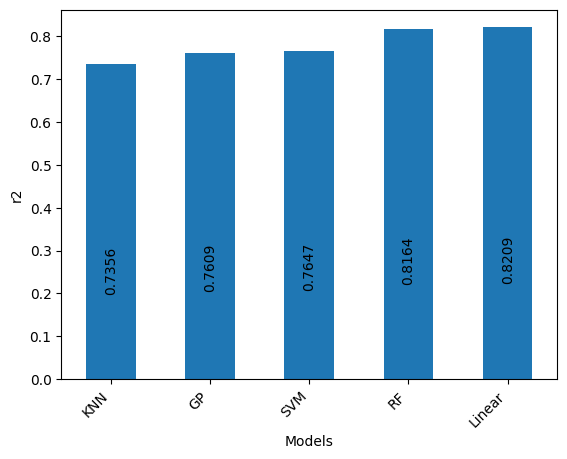

In [ ]:
dataset_name     = 'ML6'
remove_zero      = True
dataset_root     = '../../dataset'
scaler_load_path = '../../weights/Journal_paper/scaler.pkl'

if dataset_name == 'ML1_ML2':
    # Apply score to ML1/ML2 combined
    # Load Extracted features dataset

    ML1 = pd.read_excel(f'{dataset_root}/2024_02_19_ML1/feature_extraction_noise_None.xlsx')
    ML2 = pd.read_excel(f'{dataset_root}/2024_02_22_ML2/feature_extraction_noise_None.xlsx')
    
    final_dataset   = pd.concat([ML1, ML2], ignore_index=True)
    

elif dataset_name == 'ML5':
    ML5_1 = pd.read_excel(f'{dataset_root}/ML5/feature_extraction_noise_None.xlsx')
    final_dataset = ML5_1

elif dataset_name == 'ML6':
    # Load Extracted features dataset
    ML6_1 = pd.read_excel(f'{dataset_root}/ML6/Day 1 Data/feature_extraction_noise_None.xlsx')
    ML6_2 = pd.read_excel(f'{dataset_root}/ML6/Day 2 Data/feature_extraction_noise_None.xlsx')
    
    ML6_1['dataset_name'] = '1'
    ML6_2['dataset_name'] = '2'
    final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
    final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
    final_dataset['label'] = final_dataset['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
    _, final_dataset  = train_test_split(final_dataset, test_size=0.4, shuffle=True, random_state=42, stratify=final_dataset['label'])


final_dataset['label'] = final_dataset['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
final_dataset.rename(columns={"PH": 'max(S)', 'signal_std':'std(S)', 'signal_mean':'mean(S)', 'peak area':'area(S)', \
                        'dS_dV_area':'area(dS/dV)', 'dS_dV_max_peak':'max(dS/dV)', 'dS_dV_min_peak':'min(dS/dV)',\
                    'dS_dV_peak_diff':'max(dS/dV) - min(dS/dV)', \
                    'peak V':'V_max(S)', 'dS_dV_max_V':'V_max(dS/dV)', 'dS_dV_min_V':'V_min(dS/dV)',\
        }, inplace = True)



final_dataset = final_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2', 'file', 'label']]
X = final_dataset.drop(['label', 'file'], axis=1)
y = final_dataset['label']


if remove_zero:
    indx_gt_zero    = list(y[y!=0].index)
    X         = X.loc[indx_gt_zero]
    y         = y.loc[indx_gt_zero]

if dataset_name == 'ML1_ML2':
    scaler_prime = StandardScaler()

    # Z-Score Normalization on ML1_ML2 dataset
    X_scaled     = scaler_prime.fit_transform(X)
    X_scaled     = pd.DataFrame(X_scaled, columns=X.columns)
    
    if scaler_load_path != '':
        with open('../../weights/Journal_paper/scaler.pkl', 'rb') as f:
            scaler_ML6 = load(f)
            
    X_scaled = X_scaled.mul(scaler_ML6.scale_)        # Multiply the each column with the respective sigma
    X        = X_scaled.add(scaler_ML6.mean_, axis=1) # Add column wise mean

models      = ['RF', 'KNN', 'GP', 'SVM', 'Linear']
root_dir    = f'../../results/Journal_paper/{dataset_name}_zero_removal'
weight_path = '../../weights/Journal_paper'

testPerformanceWithStratified(X, y, models, root_dir, weight_path, features_list, param_list, y_LOD=y_LOD, use_classifier=False)

# Evaluation of validation performance

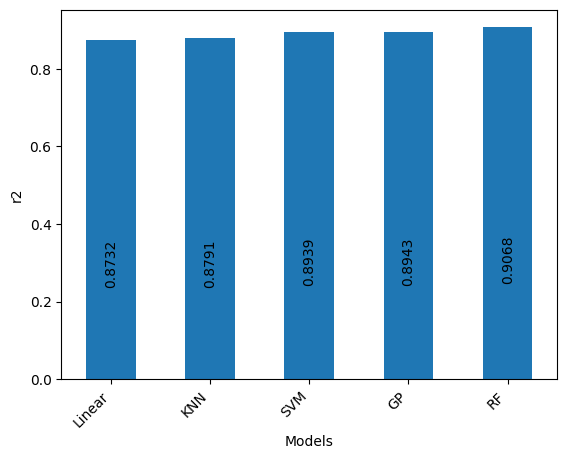

{'Models': ['KNN', 'RF', 'SVM', 'Linear', 'GP'], '0': [0.0, 0.1513697809266278, 8.81974490114556, 40.01340638506441, 18.342979480864493], '4': [15.786823725352011, 14.568344155844162, 27.99948372925955, 38.753349661034605, 26.923293921688813], '8': [25.175446539425383, 20.366849816849825, 20.231951872386407, 15.718493806773056, 20.846189676914722], '12': [12.962763700280616, 11.021820497746424, 10.795047689324889, 12.643204257197496, 11.910311069719343], '16': [13.911276232954616, 11.349805402930402, 12.876022745691282, 17.36055742993826, 12.40565385450694]}


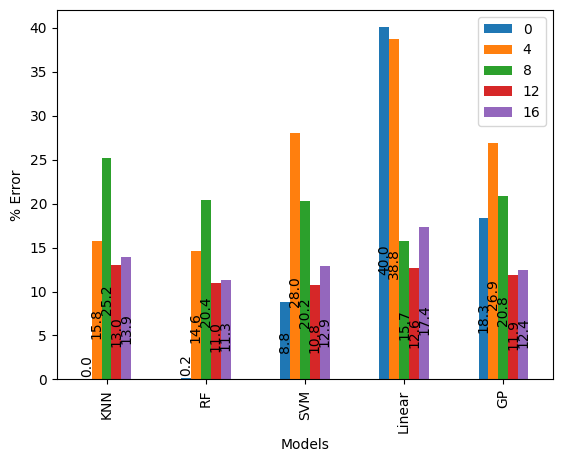

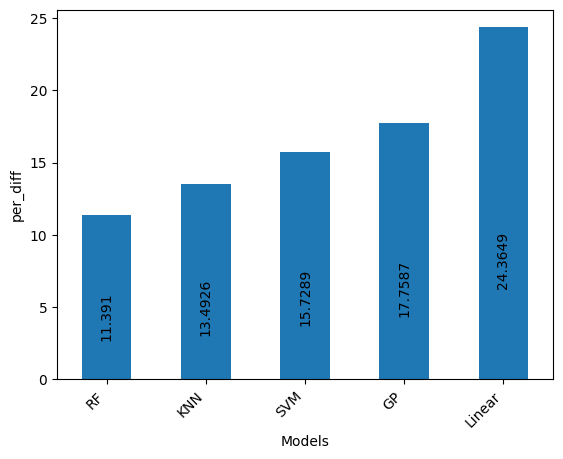

In [25]:
dataset_name = 'ML6'
remove_zero  = False
dataset_root = '../../dataset'

# Load Extracted features dataset
ML6_1 = pd.read_excel(f'{dataset_root}/ML6/Day 1 Data/feature_extraction_noise_None.xlsx')
ML6_2 = pd.read_excel(f'{dataset_root}/ML6/Day 2 Data/feature_extraction_noise_None.xlsx')

ML6_1['dataset_name'] = '1'
ML6_2['dataset_name'] = '2'
final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
final_dataset['label'] = final_dataset['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))

final_dataset.rename(columns={"PH": 'max(S)', 'signal_std':'std(S)', 'signal_mean':'mean(S)', 'peak area':'area(S)', \
                        'dS_dV_area':'area(dS/dV)', 'dS_dV_max_peak':'max(dS/dV)', 'dS_dV_min_peak':'min(dS/dV)',\
                    'dS_dV_peak_diff':'max(dS/dV) - min(dS/dV)', \
                    'peak V':'V_max(S)', 'dS_dV_max_V':'V_max(dS/dV)', 'dS_dV_min_V':'V_min(dS/dV)',\
        }, inplace = True)

final_dataset = final_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2', 'file', 'label']]

# Remove outliers from training dataset
train, test           = train_test_split(final_dataset, test_size=0.4, shuffle=True, random_state=42, stratify=final_dataset['label'])
X_filtered, outlier_S = find_outliers_remove('max(S)',  train, save_path='')
X_filtered, outlier_S = find_outliers_remove('V_max(S)',  X_filtered, save_path='')

X_train = X_filtered.drop(['label', 'file'], axis=1)
y_train = X_filtered['label']
X_test  = test.drop(['label', 'file'], axis=1)
y_test  = test['label']


models      = ['KNN', 'RF', 'SVM', 'Linear', 'GP']
root_dir    = f'../../results/Journal_paper/{dataset_name}_zero_removal'
weight_path = '../../weights/Journal_paper'

kf        = KFold(n_splits=5, shuffle=True, random_state=42) 

ValidationPerformanceWithStratified(X_train, 
                                    y_train, 
                                    models, 
                                    root_dir, 
                                    kf=kf, 
                                    features_list=features_list, 
                                    param_list= param_list, 
                                    y_LOD=y_LOD,
                                    remove_zero=remove_zero,
                                    use_classifier=False)

# Prediction per rows

In [ ]:
model_name = 'KNN'
y_LOD      = 1.0163597575709407

with open(f'{weight_path}/{model_name}.pkl', 'rb') as f:
    model = load(f)

model.set_params(**param_list[model_name])
selected_feature_set = features_list[model_name]

y_pred    = model.predict(X[selected_feature_set])
output_df = pd.DataFrame({'y_pred':y_pred, 'y_test':y})

output_df['per_error'] = output_df.apply(compute_percent_error_per_file, axis=1)
final = output_df.join(final_dataset[['file']], how='inner')

final['file'] = final['file'].apply(lambda x: x.split('/')[-1])
sorted_final_result = final.sort_values('per_error', ascending=False)

sorted_final_result.to_excel(f'../../results/{dataset_name}_per_row_per_error_{model_name}.xlsx')

In [ ]:
def compute_percent_error_per_file(x):
    y_pred, y_test =  x['y_pred'], x['y_test']
    y_pred         = max(y_pred, 0.0)

    # Only for non zero concentration
    if y_test != 0:
        per_error = abs(y_test - y_pred) * (2 / (y_test + y_pred))
    else:   
        per_error     = abs(y_test - y_pred) *  (2 / (y_LOD + y_pred))

    assert not(np.isnan(per_error))

    per_error         = per_error * 100

    return per_error

In [ ]:
c   = pd.DataFrame({'a':[1, 2, 3], 'b':[4, 5, 6]})
a   = np.array([2, 3])
b   = np.array([1, 2])
c.add(b, axis=1)

In [ ]:
# features_list= {'KNN':['min(dS/dV)', 'V_min(dS/dV)'], 
#                 'Linear':['min(dS/dV)', 'V_max(S)', 'f2'], 
#                 'RF':['min(dS/dV)', 'f2', 'f1', 'max(S)'], 
#                 'SVM':['min(dS/dV)', 'area(S)', 'V_max(S)', 'max(dS/dV)'], 
#                 'GP':['min(dS/dV)', 'vcenter', 'max(S)']}


# param_list = {'KNN': {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'},
#               'Linear': {},
#               'RF': {'n_estimators': 120, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 1,  'max_features': 5},
#               'SVM':{'C': 200, 'gamma': 1.0, 'kernel': 'rbf'},
#               'GP': {'kernel': 1**2 * RBF(length_scale=1), 'alpha': 1.0}}

# add_alpha = False
# per_diff_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}


# models      = ['KNN', 'RF', 'SVM', 'Linear', 'GP']
# root_path   = '../results/Journal_paper'
# weight_path = '../weights/Journal_paper'
# os.makedirs(weight_path, exist_ok=True)

# y_LOD     = calculate_y_LOD(X, y)
# print(y_LOD)
# for metric in ['r2', 'per_diff']:
#     test_score = {'Models':[], 'Scores':[]}
#     for model_name in models:
#         with open(f'{weight_path}/{model_name}.pkl', 'rb') as f:
#             model = load(f)
            
#         selected_feature_set = features_list[model_name]
        
#         # Calculate the test score on the given performance metrics
#         test_score['Models'].append(model_name)
    
#         y_pred = model.predict(X[selected_feature_set])
#         score  = find_score(y, y_pred, y_LOD=y_LOD, metric=metric, use_adjusted_r2=False, feature_len=len(selected_feature_set))
#         test_score['Scores'].append(score)

#         if (metric == 'per_diff'):
#             per_diff_class_stratified_test['Models'].append(model_name)
#             temp_output_per_diff = evaluate_score_class_stratified(y_pred, y, score='per_diff', y_LOD=y_LOD)
#             for label in y.unique():
#                 per_diff_class_stratified_test[str(label)].append(temp_output_per_diff[label]['score'])

#     if (metric=='per_diff'):
#         visualization_class_stratified(per_diff_class_stratified_test, f'{root_path}/stratified_results/per_error_class_stratified.png')
    
#     save_path = os.path.join(root_path, f'Test_Results/test_results_{metric}.png')
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     df_test_score = pd.DataFrame(test_score)
#     df_test_score = df_test_score.sort_values(by='Scores')
#     plot_model_vs_score(df_test_score, metric, save_path)
#     plt.show()

In [ ]:
a = np.array([1,2,3,4,4,4,0])
print(np.sort(np.unique(a)))
a = pd.Series(a)
a.to_numpy()

In [ ]:
list(a[a!=0].index)

In [ ]:
c= {'a':1, 'b':2}
c

In [ ]:
c.pop()

In [ ]:
c